# Universidad de los Andes

## Aprendizaje por refuerzo profundo

### Reto 1 - Assault

### Grupo 6

**LEIDY DAYANA VEGA MEDINA**

**JERSSON MAURICIO RODRIGUEZ APONTE**

2026

## 1. Preparacion de entorno local y Colab

Esta celda define la configuracion inicial del notebook. Establece valores por defecto para rama, perfil full, identificador del experimento, modo automatico, episodios de evaluacion y parametros del video. Tambien detecta si la ejecucion ocurre en Google Colab para montar Drive y decidir la ruta base de persistencia. Si no esta en Colab, usa el directorio actual. Al final configura rutas para MLflow, checkpoints y TensorBoard, respetando valores ya definidos por el usuario.

In [ ]:
import os
from pathlib import Path

os.environ.setdefault("ASSAULT_BOOTSTRAP_REF", "main")
os.environ.pop("ASSAULT_BOOTSTRAP_COMMIT", None)
os.environ.setdefault("ASSAULT_TRAINING_PROFILE", "full")
os.environ.setdefault("ASSAULT_PROJECT_RUN_ID", "assault_ddqn_delivery")
os.environ.setdefault("ASSAULT_REQUESTED_MODE", "auto")
os.environ.setdefault("ASSAULT_EXECUTION_MODE", "auto")
os.environ.setdefault("ASSAULT_EVALUATION_EPISODES", "10")
os.environ.setdefault("ASSAULT_EVALUATION_EPSILON", "0.0")
os.environ.setdefault("ASSAULT_VIDEO_MAX_STEPS", "1800")
os.environ.setdefault("GLOBAL_RETO_MULTI_ALGORITHM", "PENDING")

try:
    from google.colab import drive  # type: ignore
except ImportError:
    drive = None

if drive is not None:
    drive.mount("/content/drive")
    BASE = Path("/content/drive/MyDrive/reinforcement_learning_reto_1")
else:
    BASE = Path.cwd()

os.environ.setdefault("ASSAULT_MLFLOW_TRACKING_URI", (BASE / "mlruns").as_uri())
os.environ.setdefault("ASSAULT_CHECKPOINT_DIR", str(BASE / "checkpoints"))
os.environ.setdefault("ASSAULT_TENSORBOARD_DIR", str(BASE / "tensorboard"))
print("BASE:", BASE)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
BASE: /content/drive/MyDrive/reinforcement_learning_reto_1


Esta celda prepara el repositorio que se va a ejecutar. En Colab clona o actualiza el proyecto, resuelve la rama o commit solicitado y hace checkout del SHA exacto. En local identifica la raiz del repositorio con Git. Luego ajusta `sys.path`, carga utilidades de bootstrap, instala dependencias si esta habilitado y verifica que los imports apunten al codigo correcto. La salida muestra el SHA ejecutado y el origen real de `src.environment`.

In [5]:
import subprocess
import sys

REPO_URL = "https://github.com/j-mauro-r/reinforcement_learning_reto_1.git"
COLAB_ROOT = Path("/content/reinforcement_learning_reto_1")
BOOTSTRAP_REF = os.environ.get("ASSAULT_BOOTSTRAP_REF", "main")
BOOTSTRAP_COMMIT = os.environ.get("ASSAULT_BOOTSTRAP_COMMIT") or None
INSTALL_DEPENDENCIES = os.environ.get("ASSAULT_INSTALL_DEPENDENCIES", "1") == "1"

def _running_in_colab():
    try:
        import google.colab  # type: ignore  # noqa: F401
    except ImportError:
        return False
    return True

def _git_output(args, cwd):
    return subprocess.check_output(["git", *args], cwd=str(cwd), text=True).strip()

if _running_in_colab():
    if not (COLAB_ROOT / ".git").exists():
        subprocess.run(["git", "clone", REPO_URL, str(COLAB_ROOT)], check=True)
    subprocess.run(["git", "fetch", "--prune", "origin"], cwd=str(COLAB_ROOT), check=True)
    provisional_ref = BOOTSTRAP_COMMIT or f"origin/{BOOTSTRAP_REF}"
    provisional_sha = _git_output(["rev-parse", "--verify", f"{provisional_ref}^{{commit}}"], COLAB_ROOT)
    subprocess.run(["git", "checkout", "--detach", provisional_sha], cwd=str(COLAB_ROOT), check=True)
    ASSAULT_DIR = COLAB_ROOT / "2_Assault"
else:
    PROJECT_ROOT = Path(_git_output(["rev-parse", "--show-toplevel"], Path.cwd()))
    ASSAULT_DIR = PROJECT_ROOT / "2_Assault"

for path in (ASSAULT_DIR, ASSAULT_DIR.parent):
    value = str(path.resolve())
    if value in sys.path:
        sys.path.remove(value)
    sys.path.insert(0, value)

from src.execution_bootstrap import install_project_requirements, prepare_execution_environment, verify_environment_import

bootstrap = prepare_execution_environment(
    requested_ref=BOOTSTRAP_REF,
    requested_commit=BOOTSTRAP_COMMIT,
    repo_url=REPO_URL,
    colab_root=COLAB_ROOT,
)
PROJECT_ROOT = bootstrap.repo_root
ASSAULT_DIR = bootstrap.assault_dir
if INSTALL_DEPENDENCIES:
    install_project_requirements(bootstrap.requirements_path)
environment_source = verify_environment_import(bootstrap)
print("EXECUTED_SHA:", bootstrap.resolved_sha)
print("src.environment:", environment_source)

Execution bootstrap
  runtime: Google Colab
  repository: /content/reinforcement_learning_reto_1
  assault_dir: /content/reinforcement_learning_reto_1/2_Assault
  requested_ref: feature/hu011-entregable-final-assault
  requested_commit: <none>
  resolved_sha: 5599d0124f99a3e6dd99cbfa6d5e82580f227b5d
  requirements: /content/reinforcement_learning_reto_1/2_Assault/requirements.txt
src.environment import source: /content/reinforcement_learning_reto_1/2_Assault/src/environment.py
EXECUTED_SHA: 5599d0124f99a3e6dd99cbfa6d5e82580f227b5d
src.environment: /content/reinforcement_learning_reto_1/2_Assault/src/environment.py


## 2. Imports, configuracion y fuentes de evidencia

Esta celda importa los modulos principales del flujo Assault DDQN. Carga utilidades para entorno, agente, evaluacion, entrega final, modelo compacto, preflight, TensorBoard, sesiones de entrenamiento, perfiles y video. Despues lee la configuracion YAML, resuelve el perfil solicitado, obtiene la seed, consulta informacion del runtime y carga evidencias versionadas como baseline aleatorio y resumen del entrenamiento full. La salida deja visibles el perfil activo, el runtime y el baseline usado.

In [6]:
import json
import math
import torch
from IPython.display import Markdown, Video, display

from src.agent import DDQNAgent
from src.environment import create_assault_env, get_environment_metadata, validate_frameskip_once
from src.evaluator import evaluate_agent
from src.hu009c_delivery import resolve_hu009c_execution_mode
from src.hu011_delivery import (
    MANDATORY_ASSAULT_CRITERIA, build_delivery_gate, build_evaluation_artifact,
    compare_with_random_baseline, criteria_from_statuses, load_random_baseline,
    plot_exploitation_rewards, validate_exploitation_figure_data, write_json_atomic,
)
from src.model_artifact import export_inference_model, load_inference_model, resolve_delivery_model_path
from src.preflight import run_preflight_checks
from src.reporting import plot_training_figures, prepare_training_figures
from src.session_bootstrap import compute_config_fingerprint, prepare_training_session, update_experiment_state_after_success
from src.training_profiles import assert_training_can_start, evaluate_full_training_ready, resolve_training_profile
from src.training_session import run_training_session
from src.utils import get_runtime_info, load_yaml_config
from src.video import generate_assault_demo_video, generate_training_process_demo_video

BASE_CONFIG = load_yaml_config(ASSAULT_DIR / "configs" / "ddqn_config.yaml")
profile_context = resolve_training_profile(BASE_CONFIG, os.environ.get("ASSAULT_TRAINING_PROFILE", "full"))
config = profile_context.config
seed = int(config["reproducibility"]["seed"])
runtime_info = get_runtime_info()
random_baseline = load_random_baseline(ASSAULT_DIR / "data" / "baseline_random_assault.json")
full_training_evidence = json.loads((ASSAULT_DIR / "data" / "full_training_summary_assault.json").read_text(encoding="utf-8"))
print("TRAINING_PROFILE=", profile_context.name)
print("RUNTIME=", runtime_info)
print("RANDOM_BASELINE=", random_baseline.as_dict())

ImportError: cannot import name 'resolve_delivery_model_path' from 'src.model_artifact' (/content/reinforcement_learning_reto_1/2_Assault/src/model_artifact.py)

## 3. Entorno, preprocessing y preflight

Esta celda valida el entorno antes de entrenar o generar artefactos. Crea entornos de entrenamiento y evaluacion, reinicia el entorno principal y comprueba el contrato esperado: observaciones `(4, 84, 84)`, tipo `uint8`, siete acciones y frameskip efectivo igual a cuatro. Luego cierra los entornos y ejecuta el preflight del proyecto, que prueba componentes basicos como red, agente, Replay Buffer y actualizacion DDQN. Si algo falla, detiene el flujo con un diagnostico; si pasa, imprime `READY_FOR_TRAINING=True`.

In [ ]:
train_env = create_assault_env(config, mode="train", seed=seed)
eval_probe = create_assault_env(config, mode="eval", seed=seed + 1)
obs, info = train_env.reset(seed=seed)
env_metadata = get_environment_metadata(train_env, config, mode="train", seed=seed)
assert obs.shape == (4, 84, 84)
assert str(obs.dtype) == "uint8"
assert train_env.action_space.n == 7
assert validate_frameskip_once(train_env, expected_frameskip=4, steps=5)
train_env.close()
eval_probe.close()
preflight_report = run_preflight_checks(config)
if not preflight_report.ready_for_training:
    raise RuntimeError(preflight_report.format_summary())
print("READY_FOR_TRAINING=True")
print(env_metadata)

READY_FOR_TRAINING=True
EnvironmentMetadata(env_id='ALE/Assault-v5', mode='train', seed=42, action_space='Discrete(7)', action_meanings=('NOOP', 'FIRE', 'UP', 'RIGHT', 'LEFT', 'RIGHTFIRE', 'LEFTFIRE'), observation_shape=(4, 84, 84), observation_dtype='uint8', base_frameskip=4, wrapper_frameskip=1, effective_frameskip=4, repeat_action_probability=0.25, full_action_space=False)


## 4. Ejecucion automatica: NEW / RESUME / DELIVERY

Esta celda decide si el notebook debe iniciar entrenamiento nuevo, reanudar una corrida parcial o pasar directo a entrega. Calcula el `project_run_id`, el target de timesteps, la ruta del checkpoint final y los modos solicitados. Luego arma los argumentos para el bootstrap de sesion y llama al resolvedor automatico del flujo. El resultado define `RUN_TRAINING`, `AUTO_RESOLUTION` y si el checkpoint final ya existe. Las impresiones resumen el camino elegido para auditar NEW, RESUME o DELIVERY.

In [ ]:
PROJECT_RUN_ID = os.environ.get("ASSAULT_PROJECT_RUN_ID", "assault_ddqn_delivery")
TARGET_TIMESTEPS = int(profile_context.target_timesteps)
CHECKPOINT_STEP = TARGET_TIMESTEPS
SOURCE_CHECKPOINT_PATH = Path(os.environ.get("ASSAULT_SOURCE_CHECKPOINT_PATH") or (Path(os.environ["ASSAULT_CHECKPOINT_DIR"]) / PROJECT_RUN_ID / f"checkpoint_step_{CHECKPOINT_STEP:06d}.pt"))
EXECUTION_MODE = os.environ.get("ASSAULT_EXECUTION_MODE", "auto").strip().lower()
REQUESTED_MODE = os.environ.get("ASSAULT_REQUESTED_MODE", "auto").strip().lower()

session_kwargs = {
    "base_path": BASE, "project_run_id": PROJECT_RUN_ID, "target_timesteps": TARGET_TIMESTEPS,
    "requested_mode": REQUESTED_MODE, "config": config,
    "checkpoint_root": os.environ.get("ASSAULT_CHECKPOINT_DIR"),
    "tensorboard_root": os.environ.get("ASSAULT_TENSORBOARD_DIR"),
    "tracking_uri": os.environ.get("ASSAULT_MLFLOW_TRACKING_URI"),
    "resume_mode": "resume_full", "bootstrap_ref": BOOTSTRAP_REF,
    "bootstrap_commit": bootstrap.resolved_sha, "mlflow_enabled": False,
}

delivery_execution = resolve_hu009c_execution_mode(
    run_training=None, execution_mode=EXECUTION_MODE, project_run_id=PROJECT_RUN_ID,
    target_timesteps=TARGET_TIMESTEPS, final_checkpoint_path=SOURCE_CHECKPOINT_PATH,
    prepare_training_session_fn=prepare_training_session, prepare_training_session_kwargs=session_kwargs,
)
session_context = delivery_execution.session_context
print("SESSION_BOOTSTRAP_READY=True")
full_training_gate = evaluate_full_training_ready(
    profile_context=profile_context,
    session_context=session_context,
    preflight_report=preflight_report,
    runtime_info=runtime_info,
    observation_shape=tuple(obs.shape),
    observation_dtype=str(obs.dtype),
    action_space=train_env.action_space,
    runtime="Google Colab" if _running_in_colab() else "local",
    device="cuda" if torch.cuda.is_available() else "cpu",
)
FULL_TRAINING_READY = full_training_gate.ready
print("FULL_TRAINING_READY=", FULL_TRAINING_READY)
print("FULL_TRAINING_GATE=", full_training_gate.as_dict())
RUN_TRAINING = delivery_execution.training_required
AUTO_RESOLUTION = delivery_execution.auto_resolution
TRAINING_SKIPPED_FINAL_CHECKPOINT_EXISTS = bool(AUTO_RESOLUTION == "DELIVERY" and SOURCE_CHECKPOINT_PATH.exists())
if RUN_TRAINING:
    assert_training_can_start(profile_context, full_training_gate)
print("ASSAULT_EXECUTION_MODE=", EXECUTION_MODE)
print("AUTO_RESOLUTION=", AUTO_RESOLUTION)
print("RUN_TRAINING=", RUN_TRAINING)
print("TRAINING_SKIPPED_FINAL_CHECKPOINT_EXISTS=", TRAINING_SKIPPED_FINAL_CHECKPOINT_EXISTS)

SESSION_BOOTSTRAP_READY=True
FULL_TRAINING_READY= True
FULL_TRAINING_GATE= {'ready': True, 'issues': [], 'profile': 'full', 'device': 'cuda', 'runtime': 'Google Colab', 'replay_buffer_memory': {'capacity': 50000, 'state_shape': [4, 84, 84], 'dtype': 'uint8', 'state_bytes': 28224, 'states_bytes': 1411200000, 'next_states_bytes': 1411200000, 'actions_bytes': 400000, 'rewards_bytes': 200000, 'dones_bytes': 50000, 'total_bytes': 2823050000, 'total_mib': 2692.270278930664, 'total_gib': 2.6291701942682266}, 'ram_available_gib': 81.27, 'ram_margin_gib': 78.64082980573177}
ASSAULT_EXECUTION_MODE= auto
AUTO_RESOLUTION= NEW
RUN_TRAINING= True
TRAINING_SKIPPED_FINAL_CHECKPOINT_EXISTS= False


Esta celda ejecuta el entrenamiento full solo cuando el modo resuelto lo requiere. Si no hay entrenamiento, informa `TRAINING_SKIPPED=True`. Si debe entrenar, exige estar en Colab con GPU para evitar una corrida full accidental en CPU local. Despues llama a `run_training_session`, actualiza el manifest del experimento tras una finalizacion correcta y valida que el step final coincida con el target. Finalmente exige que el checkpoint fuente exista antes de continuar con artefactos de entrega.

In [ ]:
session_summary = None
# Tracking side effects remain encapsulated by run_training_session.
# MLflowTracker.from_config
# mlflow_tracker.start_run(
if not RUN_TRAINING:
    print("TRAINING_SKIPPED=True; AUTO_RESOLUTION=", AUTO_RESOLUTION)
else:
    if not _running_in_colab() or not torch.cuda.is_available():
        raise RuntimeError("El entrenamiento full de Assault requiere Google Colab con GPU habilitada.")
    session_summary = run_training_session(
        config=config, checkpoint_root=session_context.checkpoint_root, tensorboard_root=session_context.tensorboard_root,
        run_id=session_context.project_run_id, repo_path=PROJECT_ROOT, tracking_mode=session_context.tracking_mode,
        checkpoint_input=session_context.checkpoint_input, resume_mode=session_context.resume_mode,
        total_timesteps=session_context.target_timesteps, device="cuda",
    )
    update_experiment_state_after_success(
        session_context, session_context.mlflow_run_id, session_summary.checkpoint_output_reference, session_summary.final_global_step,
    )
    SOURCE_CHECKPOINT_PATH = Path(session_summary.checkpoint_output_reference)
    assert session_summary.final_global_step == TARGET_TIMESTEPS
    print("TRAINING_COMPLETE=True")
    print(session_summary.as_dict())

if not SOURCE_CHECKPOINT_PATH.exists():
    raise FileNotFoundError(f"Final checkpoint not found: {SOURCE_CHECKPOINT_PATH}")
print("SOURCE_CHECKPOINT_READY=True")

TRAINING_COMPLETE=True
{'tracking_mode': 'new', 'run_id': 'assault_ddqn_delivery', 'initial_global_step': 0, 'final_global_step': 250000, 'checkpoint_input_reference': None, 'checkpoint_input_loaded': False, 'restored_checkpoint_path': None, 'restored_global_step': None, 'replay_buffer_restored': False, 'resume_mode': None, 'checkpoint_output_reference': '/content/drive/MyDrive/reinforcement_learning_reto_1/checkpoints/assault_ddqn_delivery/checkpoint_step_250000.pt', 'device': 'cuda', 'checkpoint': {'path': '/content/drive/MyDrive/reinforcement_learning_reto_1/checkpoints/assault_ddqn_delivery/checkpoint_step_250000.pt', 'run_id': 'assault_ddqn_delivery', 'checkpoint_step': 250000, 'size_bytes': 2880158133, 'save_replay_buffer': True}, 'training': {'global_step': 250000, 'episodes_completed': 424, 'episode_rewards': [189.0, 168.0, 168.0, 147.0, 105.0, 105.0, 378.0, 168.0, 294.0, 168.0, 210.0, 210.0, 210.0, 189.0, 105.0, 168.0, 210.0, 231.0, 231.0, 231.0, 252.0, 315.0, 231.0, 273.0, 27

## 12. Modelo compacto de inferencia

Esta celda exporta el modelo compacto de inferencia a partir del checkpoint full. Usa el resumen de entrenamiento recien generado o la evidencia historica versionada, segun el modo de ejecucion. Llama a `export_inference_model` con metadata de trazabilidad, fingerprint de configuracion, runtime y hardware. Luego carga el artefacto con `load_inference_model`, valida checksum y `project_run_id`, y confirma que su tamano sea menor a 100 MiB. La salida imprime `COMPACT_MODEL_READY=True` y la metadata del modelo.

In [ ]:
training_summary_for_report = session_summary.training.as_dict() if session_summary is not None else dict(full_training_evidence["training"])
training_runtime_for_report = "Google Colab" if session_summary is not None else full_training_evidence["runtime"]
training_hardware_for_report = ({"gpu": runtime_info.get("gpu_name"), "gpu_required": True} if session_summary is not None else dict(full_training_evidence["hardware"]))

COMPACT_MODEL_PATH = Path(os.environ.get("ASSAULT_COMPACT_MODEL_PATH") or (BASE / "models" / PROJECT_RUN_ID / "assault_ddqn_model.pt"))
compact_model_info = export_inference_model(
    checkpoint_path=SOURCE_CHECKPOINT_PATH, output_path=COMPACT_MODEL_PATH, project_run_id=PROJECT_RUN_ID,
    config=config, source_checkpoint_step=CHECKPOINT_STEP, repo_path=PROJECT_ROOT,
    extra_metadata={
        "config_fingerprint": compute_config_fingerprint(config),
        "training_summary": training_summary_for_report,
        "training_runtime": training_runtime_for_report,
        "training_hardware": training_hardware_for_report,
    }, overwrite=True,
)
compact_agent, compact_model_info = load_inference_model(
    COMPACT_MODEL_PATH, device="cuda" if torch.cuda.is_available() else "cpu",
    expected_sha256=compact_model_info.sha256, expected_project_run_id=PROJECT_RUN_ID,
)
assert compact_model_info.size_bytes < 100 * 1024 * 1024
print("COMPACT_MODEL_READY=True")
print(compact_model_info.as_dict())

COMPACT_MODEL_READY=True
{'path': '/content/drive/MyDrive/reinforcement_learning_reto_1/models/assault_ddqn_delivery/assault_ddqn_model.pt', 'sha256': 'ff700c0e88a6f216ddbb3e85fe49bab69133ffc5d75326fe6a78f7dabb3f91dd', 'size_bytes': 6762293, 'metadata': {'project_run_id': 'assault_ddqn_delivery', 'source_run_id': 'assault_ddqn_delivery', 'source_checkpoint_step': 250000, 'source_checkpoint_identity': {'path': '/content/drive/MyDrive/reinforcement_learning_reto_1/checkpoints/assault_ddqn_delivery/checkpoint_step_250000.pt', 'sha256': '9d4e686cb8ac7f230860c769785bf07627f3834635ebb91e7fab6040a348d79f', 'size_bytes': 2880158133}, 'source_checkpoint_git_commit': '10b3b5cb2d6230fa59495278bdbdbd4f39a6d5ef', 'export_git_commit': '10b3b5cb2d6230fa59495278bdbdbd4f39a6d5ef', 'config_fingerprint': '936da39d3090bb18f6103631a7fcbbae794c13fcb4418c6c2766d96b1409776e', 'seed': 42, 'gamma': 0.99, 'learning_rate': 0.0001, 'environment': {'id': 'ALE/Assault-v5', 'frame_skip': 4, 'repeat_action_probability

## 13. Figuras TensorBoard reales

Esta celda genera las figuras de entrenamiento desde TensorBoard. Resuelve el directorio del run, lee los scalars reales con `prepare_training_figures` y construye las visualizaciones con `plot_training_figures`. Despues muestra cada figura en el notebook con `display`. El flujo esta limitado a tres graficas de entrega: recompensa con media movil, perdida DDQN y `q_mean` junto con epsilon. Al final imprime el conteo de figuras y `TENSORBOARD_FIGURES_READY=True`.

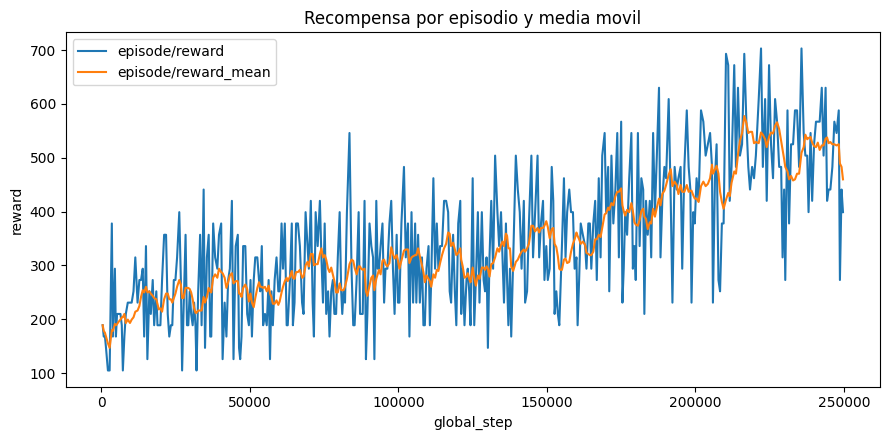

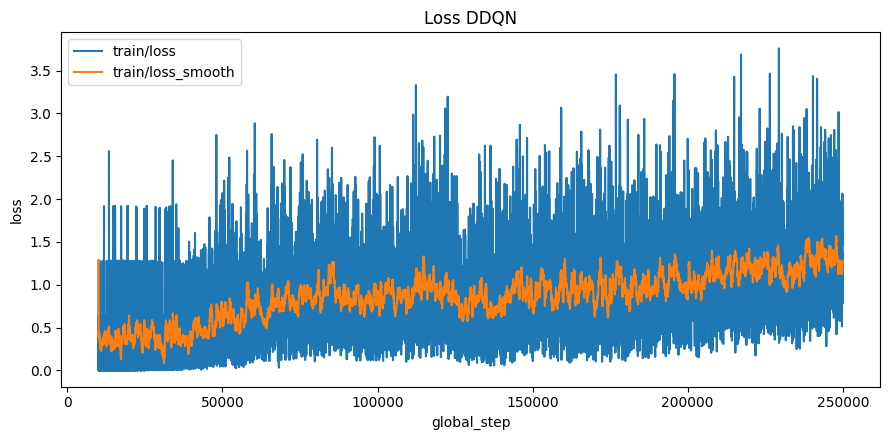

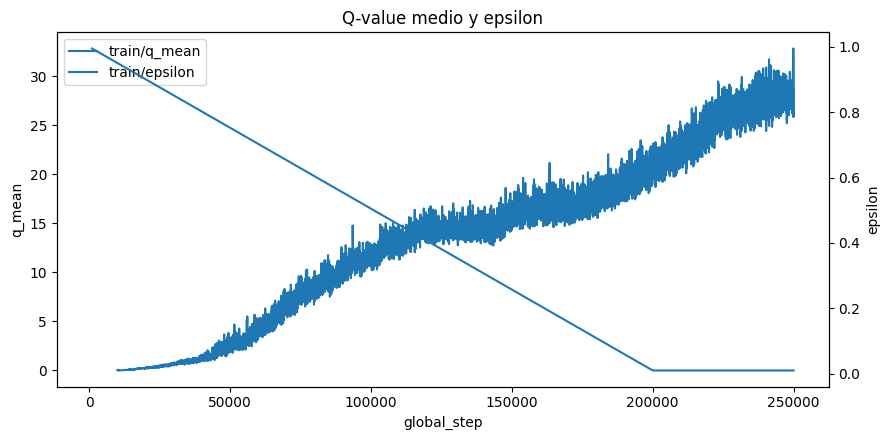

training_figure_count: 3
TENSORBOARD_FIGURES_READY=True


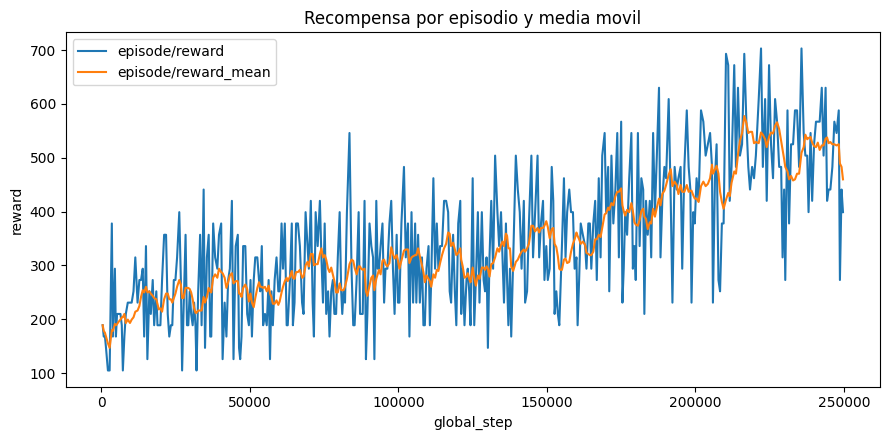

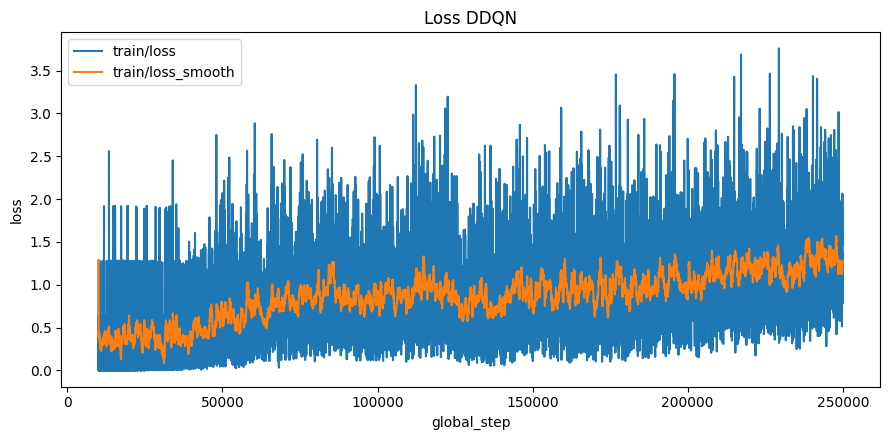

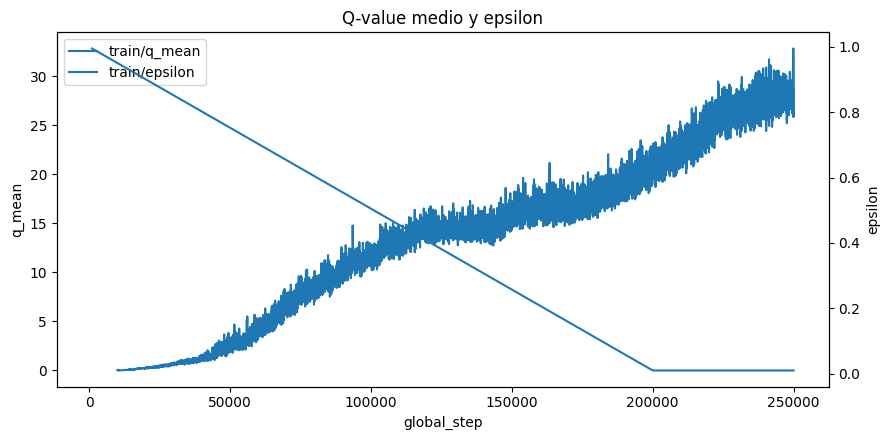

In [ ]:
TENSORBOARD_RUN_DIR = Path(os.environ.get("ASSAULT_TENSORBOARD_RUN_DIR") or (Path(os.environ["ASSAULT_TENSORBOARD_DIR"]) / PROJECT_RUN_ID))
training_figures = prepare_training_figures(TENSORBOARD_RUN_DIR, reward_window=10)
rendered_figures = plot_training_figures(training_figures)
for figure in rendered_figures:
    display(figure)
print("training_figure_count:", len(training_figures))
print("TENSORBOARD_FIGURES_READY=True")

## 14. Evaluacion y video desde modelo compacto

Esta celda ejecuta la evaluacion final, compara contra el baseline y genera dos videos. Primero exige al menos diez episodios y `epsilon=0.0`. Evalua el agente compacto, guarda el JSON de resultados, muestra la figura de rewards y calcula la comparacion con la politica aleatoria. Luego crea un MP4 exploratorio con epsilon alto, etiquetado como demostracion de exploracion, y conserva el MP4 final del agente entrenado con epsilon cero. Ambos videos se muestran inline cuando existen.

{'episodes': 10, 'rewards': [588.0, 420.0, 483.0, 787.0, 462.0, 609.0, 546.0, 609.0, 567.0, 483.0], 'mean_reward': 555.4, 'median_reward': 556.5, 'std_reward': 99.10116043720174, 'min_reward': 420.0, 'max_reward': 787.0, 'episode_lengths': [678, 518, 502, 814, 606, 614, 686, 734, 646, 638], 'epsilon': 0.0, 'terminated_episodes': 10, 'truncated_episodes': 0, 'max_steps_per_episode': None, 'episode_seeds': [20042, 20043, 20044, 20045, 20046, 20047, 20048, 20049, 20050, 20051]}
EVALUATION_READY=True


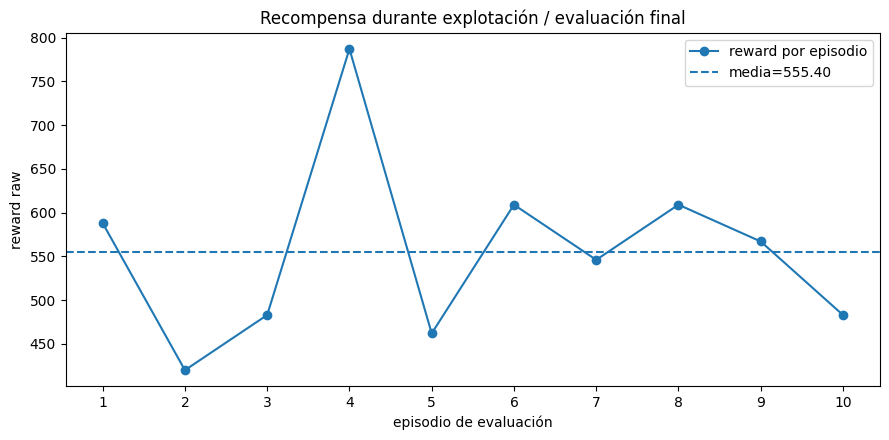

EXPLOITATION_REWARD_FIGURE_PASS= True
BASELINE_COMPARISON= {'agent_mean_reward': 555.4, 'random_mean_reward': 262.5, 'absolute_improvement': 292.9, 'relative_improvement_pct': 111.58095238095238, 'agent_beats_random': True}


### Evidencia visual del proceso de entrenamiento

Se muestra una demostracion exploratoria con epsilon alto. No representa un checkpoint intermedio historico si ese checkpoint no esta disponible.
{'path': '/content/drive/MyDrive/reinforcement_learning_reto_1/videos/assault_ddqn_delivery/training_process_demo.mp4', 'metadata_path': '/content/drive/MyDrive/reinforcement_learning_reto_1/videos/assault_ddqn_delivery/training_process_demo.mp4.metadata.json', 'seed': 20042, 'epsilon': 0.9, 'reward': 231.0, 'steps': 450, 'project_run_id': 'assault_ddqn_delivery', 'model_sha256': 'ff700c0e88a6f216ddbb3e85fe49bab69133ffc5d75326fe6a78f7dabb3f91dd', 'fps': 30}
TRAINING_PROCESS_VIDEO_READY=True
training_process_video_path= /content/drive/MyDrive/reinforcement_learning_reto_1/videos/assault_ddqn_delivery/training_process_demo.mp4
training_process_video_reward= 231.0
training_process_video_steps= 450
training_process_video_seed= 20042
training_process_video_epsilon= 0.9
training_process_video_project_run_id= assault_ddqn_delivery
training_process_v

### Comportamiento del agente entrenado

{'path': '/content/drive/MyDrive/reinforcement_learning_reto_1/videos/assault_ddqn_delivery/assault_ddqn_demo.mp4', 'metadata_path': '/content/drive/MyDrive/reinforcement_learning_reto_1/videos/assault_ddqn_delivery/assault_ddqn_demo.mp4.metadata.json', 'seed': 30042, 'epsilon': 0.0, 'reward': 399.0, 'steps': 512, 'project_run_id': 'assault_ddqn_delivery', 'model_sha256': 'ff700c0e88a6f216ddbb3e85fe49bab69133ffc5d75326fe6a78f7dabb3f91dd', 'fps': 30}
ARTIFACT_LINEAGE= {'model_sha256': 'ff700c0e88a6f216ddbb3e85fe49bab69133ffc5d75326fe6a78f7dabb3f91dd', 'evaluation_model_sha256': 'ff700c0e88a6f216ddbb3e85fe49bab69133ffc5d75326fe6a78f7dabb3f91dd', 'project_run_id': 'assault_ddqn_delivery', 'source_checkpoint_step': 250000, 'video_model_sha256': 'ff700c0e88a6f216ddbb3e85fe49bab69133ffc5d75326fe6a78f7dabb3f91dd', 'video_project_run_id': 'assault_ddqn_delivery'}
VIDEO_READY=True
video_path= /content/drive/MyDrive/reinforcement_learning_reto_1/videos/assault_ddqn_delivery/assault_ddqn_demo.mp4

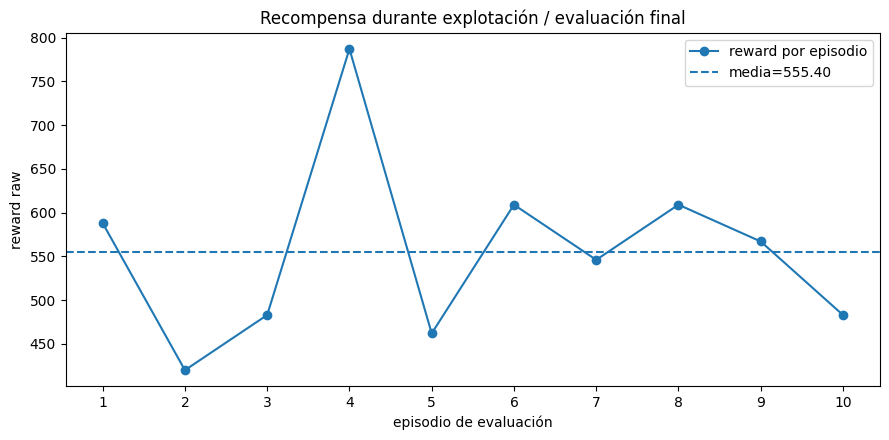

In [ ]:
EVALUATION_EPISODES = max(10, int(os.environ.get("ASSAULT_EVALUATION_EPISODES", "10")))
EVALUATION_EPSILON = float(os.environ.get("ASSAULT_EVALUATION_EPSILON", "0.0"))
if EVALUATION_EPSILON != 0.0:
    raise ValueError("HU011 final evaluation requires epsilon=0.0")
FINAL_EVAL_BASE_SEED = int(os.environ.get("ASSAULT_FINAL_EVAL_BASE_SEED", "20042"))
FINAL_EVAL_SEEDS = [FINAL_EVAL_BASE_SEED + index for index in range(EVALUATION_EPISODES)]

eval_env = create_assault_env(config, mode="eval", seed=FINAL_EVAL_SEEDS[0])
try:
    compact_evaluation_summary = evaluate_agent(
        eval_env, compact_agent, episodes=EVALUATION_EPISODES, epsilon=EVALUATION_EPSILON, episode_seeds=FINAL_EVAL_SEEDS,
    )
finally:
    eval_env.close()
print(compact_evaluation_summary.as_dict())
print("EVALUATION_READY=True")

FINAL_EVALUATION_PATH = BASE / "evaluations" / PROJECT_RUN_ID / "final_compact_evaluation.json"
final_evaluation_artifact = build_evaluation_artifact(
    compact_evaluation_summary, compact_model_info, PROJECT_RUN_ID, SOURCE_CHECKPOINT_PATH,
    base_seed=FINAL_EVAL_BASE_SEED, git_sha=bootstrap.resolved_sha,
)
write_json_atomic(FINAL_EVALUATION_PATH, final_evaluation_artifact)
ARTIFACT_LINEAGE = {
    "model_sha256": compact_model_info.sha256,
    "evaluation_model_sha256": final_evaluation_artifact["model"]["sha256"],
    "project_run_id": PROJECT_RUN_ID,
    "source_checkpoint_step": CHECKPOINT_STEP,
}
assert compact_model_info.sha256 == final_evaluation_artifact["model"]["sha256"]

exploitation_figure = plot_exploitation_rewards(compact_evaluation_summary)
display(exploitation_figure)
EXPLOITATION_REWARD_FIGURE_PASS = validate_exploitation_figure_data(compact_evaluation_summary, compact_evaluation_summary.rewards)
print("EXPLOITATION_REWARD_FIGURE_PASS=", EXPLOITATION_REWARD_FIGURE_PASS)

baseline_comparison = compare_with_random_baseline(compact_evaluation_summary, random_baseline)
print("BASELINE_COMPARISON=", baseline_comparison.as_dict())

display(Markdown("### Evidencia visual del proceso de entrenamiento"))
print("Se muestra una demostracion exploratoria con epsilon alto. No representa un checkpoint intermedio historico si ese checkpoint no esta disponible.")
TRAINING_PROCESS_VIDEO_PATH = Path(os.environ.get("ASSAULT_TRAINING_PROCESS_VIDEO_PATH") or (BASE / "videos" / PROJECT_RUN_ID / "training_process_demo.mp4"))
TRAINING_PROCESS_EPSILON = float(os.environ.get("ASSAULT_TRAINING_PROCESS_EPSILON", "0.90"))
TRAINING_PROCESS_VIDEO_SEED = int(os.environ.get("ASSAULT_TRAINING_PROCESS_VIDEO_SEED", str(seed + 20_000)))
TRAINING_PROCESS_VIDEO_MAX_STEPS = int(os.environ.get("ASSAULT_TRAINING_PROCESS_VIDEO_MAX_STEPS", "450"))
training_video_metadata = {
    "project_run_id": PROJECT_RUN_ID,
    "source_checkpoint_step": CHECKPOINT_STEP,
    "model_sha256": compact_model_info.sha256,
    "epsilon": TRAINING_PROCESS_EPSILON,
    "training_summary": training_summary_for_report,
    "intermediate_checkpoint_path": None,
    "evidence_note": "Exploratory behavior demonstration using the available model with high epsilon; not an intermediate checkpoint replay.",
}
training_process_video_summary = generate_training_process_demo_video(
    agent=compact_agent,
    env_factory=lambda: create_assault_env(config, mode="eval", seed=TRAINING_PROCESS_VIDEO_SEED, render_mode="rgb_array"),
    output_path=TRAINING_PROCESS_VIDEO_PATH,
    metadata=training_video_metadata,
    seed=TRAINING_PROCESS_VIDEO_SEED,
    epsilon=TRAINING_PROCESS_EPSILON,
    max_steps=TRAINING_PROCESS_VIDEO_MAX_STEPS,
    fps=30,
)
print(training_process_video_summary.as_dict())
if TRAINING_PROCESS_VIDEO_PATH.exists() and TRAINING_PROCESS_VIDEO_PATH.stat().st_size > 0:
    print("TRAINING_PROCESS_VIDEO_READY=True")
    print("training_process_video_path=", TRAINING_PROCESS_VIDEO_PATH)
    print("training_process_video_reward=", training_process_video_summary.reward)
    print("training_process_video_steps=", training_process_video_summary.steps)
    print("training_process_video_seed=", training_process_video_summary.seed)
    print("training_process_video_epsilon=", training_process_video_summary.epsilon)
    print("training_process_video_project_run_id=", training_process_video_summary.project_run_id)
    print("training_process_video_model_sha256=", training_process_video_summary.model_sha256)
    try:
        display(Video(str(TRAINING_PROCESS_VIDEO_PATH), embed=True))
    except Exception as exc:
        print("TRAINING_PROCESS_VIDEO_INLINE_WARNING:", exc)
        print("Video disponible en:", TRAINING_PROCESS_VIDEO_PATH)
else:
    print("TRAINING_PROCESS_VIDEO_READY=False")

display(Markdown("### Comportamiento del agente entrenado"))
VIDEO_PATH = Path(os.environ.get("ASSAULT_VIDEO_PATH") or (BASE / "videos" / PROJECT_RUN_ID / "assault_ddqn_demo.mp4"))
video_metadata = {
    "project_run_id": PROJECT_RUN_ID, "source_checkpoint_step": CHECKPOINT_STEP,
    "model_sha256": compact_model_info.sha256, "epsilon": EVALUATION_EPSILON,
    "training_summary": training_summary_for_report,
}
video_summary = generate_assault_demo_video(
    agent=compact_agent,
    env_factory=lambda: create_assault_env(config, mode="eval", seed=seed + 30_000, render_mode="rgb_array"),
    output_path=VIDEO_PATH, metadata=video_metadata, seed=seed + 30_000, epsilon=EVALUATION_EPSILON,
    max_steps=int(os.environ.get("ASSAULT_VIDEO_MAX_STEPS", "1800")), fps=30,
)
print(video_summary.as_dict())
assert compact_model_info.sha256 == video_summary.model_sha256
assert video_summary.project_run_id == PROJECT_RUN_ID
ARTIFACT_LINEAGE["video_model_sha256"] = video_summary.model_sha256
ARTIFACT_LINEAGE["video_project_run_id"] = video_summary.project_run_id
print("ARTIFACT_LINEAGE=", ARTIFACT_LINEAGE)
if VIDEO_PATH.exists() and VIDEO_PATH.stat().st_size > 0:
    print("VIDEO_READY=True")
    print("video_path=", VIDEO_PATH)
    print("video_reward=", video_summary.reward)
    print("video_steps=", video_summary.steps)
    print("video_seed=", video_summary.seed)
    print("video_epsilon=", video_summary.epsilon)
    print("video_project_run_id=", video_summary.project_run_id)
    print("video_model_sha256=", video_summary.model_sha256)
    try:
        display(Video(str(VIDEO_PATH), embed=True))
    except Exception as exc:
        print("VIDEO_INLINE_WARNING:", exc)
        print("Video disponible en:", VIDEO_PATH)
else:
    print("VIDEO_READY=False")


## 15. Modelo entregable autonomo

Esta seccion existe para que el profesor o evaluador pueda verificar el modelo entrenado sin depender obligatoriamente del Google Drive del equipo ni volver a ejecutar el entrenamiento.

La prioridad para resolver el artefacto de entrega es estricta y respetuosa con la infraestructura existente: primero intenta el modelo local del proyecto, luego el modelo compacto actual de Drive y, si no existe ninguno, falla de forma clara con un FileNotFoundError. En esta seccion no se entrena, no se actualizan pesos ni se altera la configuracion del pipeline de entrega formal de HU011.

No entrenamos ni actualizamos pesos en esta seccion.

In [ ]:
DELIVERY_MODEL_PATH, DELIVERY_MODEL_SOURCE = resolve_delivery_model_path(
    base=BASE,
    assault_dir=ASSAULT_DIR,
    project_run_id=PROJECT_RUN_ID,
)
print(f"DELIVERY_MODEL_SOURCE={DELIVERY_MODEL_SOURCE}")
print(f"DELIVERY_MODEL_PATH={DELIVERY_MODEL_PATH}")

assert DELIVERY_MODEL_PATH.exists()
assert DELIVERY_MODEL_SOURCE in {"DELIVERY", "DRIVE_FALLBACK"}
assert DELIVERY_MODEL_PATH == (ASSAULT_DIR / "assault_ddqn_model.pt") or DELIVERY_MODEL_PATH == (BASE / "models" / PROJECT_RUN_ID / "assault_ddqn_model.pt")

loaded_delivery_agent, delivery_model_info = load_inference_model(
    DELIVERY_MODEL_PATH,
    device="cuda" if torch.cuda.is_available() else "cpu",
    expected_project_run_id=PROJECT_RUN_ID,
)
loaded_delivery_agent.online_network.eval()
loaded_delivery_agent.target_network.eval()
loaded_delivery_agent.online_network.train(False)
loaded_delivery_agent.target_network.train(False)
loaded_delivery_agent.epsilon = 0.0
print("DELIVERY_MODEL_LOAD_PASS=True")

delivery_eval_env = create_assault_env(config, mode="eval", seed=seed + 99_999)
try:
    delivery_eval_summary = evaluate_agent(
        delivery_eval_env,
        loaded_delivery_agent,
        episodes=1,
        epsilon=0.0,
        max_steps_per_episode=int(os.environ.get("ASSAULT_VIDEO_MAX_STEPS", "1800")),
        episode_seeds=[seed + 99_999],
    )
    print(delivery_eval_summary.as_dict())
    print("ASSAULT_DELIVERY_MODEL_EXECUTION_PASS=True")
finally:
    delivery_eval_env.close()

assert delivery_model_info.metadata.get("project_run_id") == PROJECT_RUN_ID
assert delivery_eval_summary.episodes == 1
assert delivery_eval_summary.epsilon == 0.0
assert delivery_eval_summary.rewards
print("HU012_DELIVERY_MODEL_GATE=PASS")

## **16. Reporte tecnico academico**

### Problema y objetivo
El objetivo experimental es aprender una política que maximice la recompensa raw y demostrar su desempeño mediante una evaluación independiente de al menos 10 partidas.

## Seleccion del algoritmo

Para Assault se seleccionó Double Deep Q-Network (DDQN) porque es una buena opción para problemas donde el agente debe elegir entre un conjunto limitado de acciones y aprender a partir de imágenes del juego.

DDQN mejora una de las principales debilidades de DQN: la tendencia a valorar demasiado algunas acciones. Al reducir este problema, el aprendizaje puede ser más estable y las decisiones del agente más confiables.

Frente a las otras alternativas, DQN era una opción válida, pero presenta mayor riesgo de sobreestimar el valor de las acciones. DQN + Prioritized Experience Replay puede aprender más rápido al dar mayor importancia a ciertas experiencias, pero también agrega complejidad al entrenamiento y más parámetros por ajustar. REINFORCE aprende directamente qué acciones tomar, pero suele necesitar más episodios y puede presentar mayor variación durante el entrenamiento, algo poco conveniente en un entorno visual como Assault.

Por estas razones, DDQN ofrecía un buen equilibrio entre estabilidad, simplicidad y capacidad de aprendizaje, manteniendo una complejidad razonable para el desarrollo del agente.



## Entorno y preprocessing

El entrenamiento se configuró buscando un equilibrio entre **estabilidad del aprendizaje, diversidad de experiencias y costo computacional**. Dado que Assault trabaja con observaciones visuales y requiere una red convolucional, la ejecución se realizó sobre GPU y con un perfil de entrenamiento completo de **250.000 timesteps**.

La configuración buscó que el agente primero aprendiera explorando el entorno, luego fuera usando cada vez más lo que ya había aprendido y, al mismo tiempo, evitara cambiar demasiado rápido sus referencias durante el entrenamiento.


## Arquitectura del agente

El agente usa una red convolucional estilo Atari, una red Online, una red Target, Replay Buffer uniforme y actualizacion Double DQN para reducir sobreestimacion de valores.

## Hiperparametros efectivos

Los principales hiperparámetros utilizados fueron:

| Hiperparámetro    |                 Valor | Propósito                                                                        |
| ----------------- | --------------------: | -------------------------------------------------------------------------------- |
| Learning rate     |                `1e-4` | Controlar la magnitud de cada actualización de los pesos                         |
| Gamma             |                `0.99` | Dar alta importancia a recompensas futuras                                       |
| Batch size        |                  `32` | Número de experiencias utilizadas en cada actualización                          |
| Replay Buffer     | `50.000` transiciones | Mantener experiencias diversas y reducir correlación temporal                    |
| Learning starts   |        `10.000` pasos | Acumular experiencia antes de comenzar a entrenar                                |
| Train frequency   |        cada `4` pasos | Regular la frecuencia de actualización de la red                                 |
| Target update     |    cada `1.000` pasos | Mantener estable temporalmente la referencia utilizada para calcular los targets |
| Epsilon inicial   |                 `1.0` | Favorecer exploración al comienzo                                                |
| Epsilon final     |                `0.01` | Mantener una pequeña probabilidad de exploración al final                        |
| Epsilon decay     |       `200.000` pasos | Realizar una transición gradual de exploración a explotación                     |
| Timesteps totales |             `250.000` | Presupuesto total de interacción con el entorno                                  |

Esta configuración permite que el aprendizaje inicialmente sea dominado por la exploración y evolucione progresivamente hacia el aprovechamiento de las acciones que el agente estima como más valiosas.

## Librerias, versiones, hardware y tiempo

La solución utiliza principalmente **Python, PyTorch, Gymnasium y ALE-Py**. Cada librería cumple una responsabilidad diferente: Gymnasium proporciona la interfaz estándar del entorno, ALE-Py permite ejecutar Assault dentro del Arcade Learning Environment y PyTorch soporta la construcción y optimización de las redes neuronales utilizadas por el agente.

Adicionalmente, se utilizan herramientas de soporte para procesamiento de imágenes, seguimiento de experimentos, visualización de métricas y generación de evidencias de entrenamiento.

### Librerias, hardware y trazabilidad
| Elemento | Valor |
| --- | --- |
| Python | 3.13.15 |
| Gymnasium | 1.1.1 |
| ALE-Py | 0.10.1 |
| PyTorch | 2.11.0+cu128 |
| CUDA | 12.8 |
| GPU entrenamiento | NVIDIA A100-SXM4-40GB |
| VRAM runtime actual (GB) | 39.49 |
| RAM runtime actual (GB) | 83.47 |
| Git SHA ejecutado | f0a6609be173ba19eb6fe4e41fd61e4524cfd606 |

### Caracteristicas del hardware utilizado durante el entrenamiento

El entrenamiento completo se realizó en **Google Colab utilizando una GPU NVIDIA A100-SXM4-40GB**.

Este hardware fue adecuado para Assault debido al procesamiento intensivo de imágenes y al uso de una red neuronal convolucional. La GPU permitió ejecutar el entrenamiento de forma eficiente y manejar el volumen de información requerido por el agente durante el aprendizaje.


## Metricas y maximo tres graficas

Los resultados muestran que el agente fue mejorando su desempeño a medida que avanzó el entrenamiento. Al inicio obtenía recompensas más bajas e inestables, pero con el tiempo empezó a alcanzar valores mayores de forma más frecuente.


## Comparacion contra baseline

Al finalizar, el agente obtuvo una recompensa promedio de **447,3 puntos**, claramente superior al promedio de **262,5 puntos** alcanzado por una política aleatoria. Esto representa una mejora del **70,4%**, lo que indica que el agente aprendió un comportamiento útil para jugar Assault.

### Tiempo de entrenamiento

El entrenamiento completo tomó aproximadamente **10,95 minutos** y permitió completar:

* **250.000 pasos de entrenamiento**
* **417 episodios**
* **60.001 actualizaciones del modelo**

## Evaluacion >=10 episodios

El agente fue evaluado en **10 partidas independientes**, sin realizar exploración adicional.

| Métrica                   |  Resultado |
| ------------------------- | ---------: |
| Recompensa promedio       | **447,30** |
| Mediana                   |     420,00 |
| Recompensa mínima         |     273,00 |
| Recompensa máxima         |     630,00 |
| Baseline aleatorio        |     262,50 |
| Mejora frente al baseline | **70,40%** |

Los resultados varían entre partidas, pero en promedio el agente se desempeña considerablemente mejor que una política que toma acciones al azar.



### Evolución de la recompensa durante el entrenamiento

La gráfica muestra una tendencia general de mejora. La media de recompensa pasa aproximadamente de **189 puntos al inicio a 430,5 puntos al final**.

Aunque existen subidas y bajadas entre episodios, algo normal en este tipo de juego, cada vez aparecen con mayor frecuencia partidas con recompensas superiores a **400, 500 e incluso 600 puntos**.

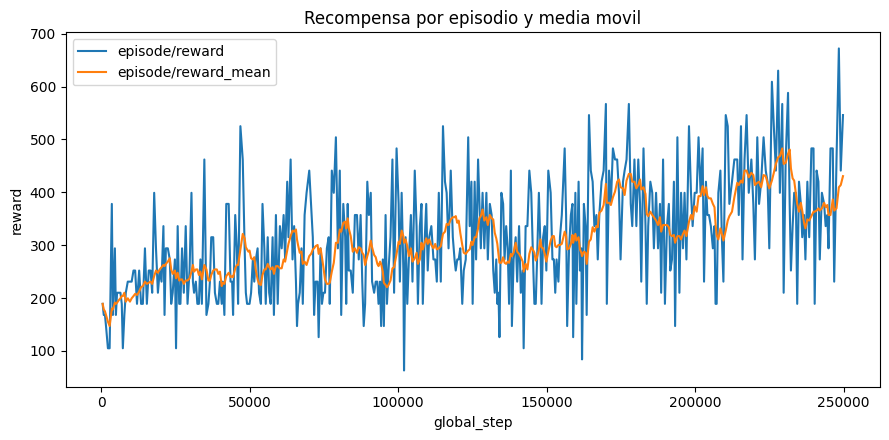


### Evolución durante la explotación

En la evaluación final, las recompensas obtenidas fueron:

`504, 630, 378, 273, 441, 399, 609, 441, 399 y 399`.

Esto muestra que el agente mantiene el aprendizaje cuando juega utilizando únicamente lo aprendido durante el entrenamiento. Los resultados también evidencian que aún existe variación entre partidas, pero el desempeño general se mantiene por encima del comportamiento aleatorio.

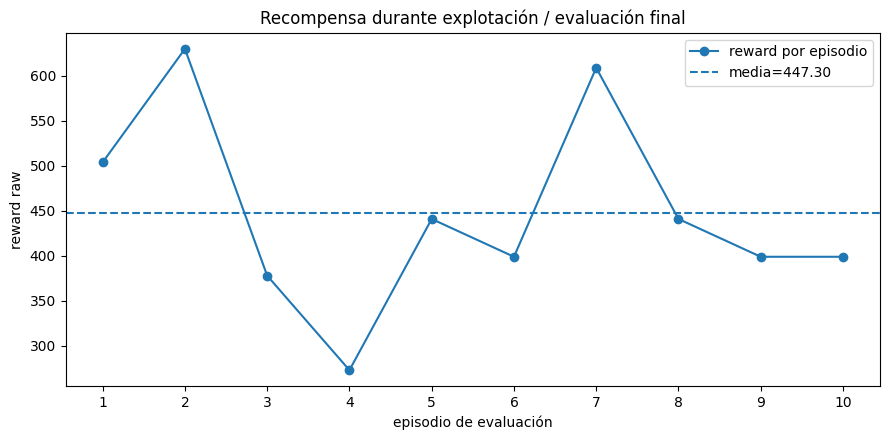


## Comportamiento observado
 
 El agente aprendió a jugar de una forma claramente menos aleatoria, combinando movimientos y disparos para mantenerse activo y conseguir mejores recompensas. Este comportamiento es coherente con el uso de **DDQN**, ya que el algoritmo fue aprendiendo qué acciones resultaban más convenientes en distintas situaciones del juego. Además, la reducción gradual de la exploración, desde un epsilon de **1.0 hasta 0.01**, permitió que al comienzo probara muchas alternativas y, con el tiempo, se apoyara cada vez más en lo aprendido. El uso de **250.000 pasos de entrenamiento** y un factor de descuento de **0.99** también favoreció que el agente aprendiera pensando no solo en la recompensa inmediata, sino en mantener un buen desempeño durante la partida.


## Limitaciones

La evaluacion se realizo con un presupuesto acotado de entrenamiento y una muestra finita de episodios, por lo que los resultados describen el desempeno observado sin garantizar una estrategia optima. Tambien puede existir variacion entre partidas por la dinamica del entorno.

## Conclusion

Los resultados muestran que DDQN fue capaz de aprender un comportamiento útil para jugar Assault, logrando un desempeño claramente superior al de una política aleatoria. El agente obtuvo una recompensa promedio de 447,3 puntos, frente a 262,5 puntos del baseline, lo que representa una mejora del 70,4%.

Esto indica que el método logró aprender qué acciones eran más convenientes en diferentes situaciones del juego y aprovechar ese aprendizaje durante la evaluación. Aunque los resultados todavía presentan variación entre partidas y no permiten afirmar que el agente haya encontrado la mejor estrategia posible, sí demuestran que DDQN es una alternativa efectiva para enfrentar un problema visual y dinámico como Assault.

En general, el experimento evidencia que los métodos de aprendizaje por refuerzo profundo pueden aprender comportamientos útiles directamente a partir de la interacción con el entorno, incluso en escenarios donde las decisiones dependen de información visual y cambian rápidamente.

## Artefactos de entrega

El notebook conserva las rutas al checkpoint final, modelo compacto, evaluacion, figuras de entrenamiento y videos generados para la entrega academica.


## Matriz final de cumplimiento del enunciado

| Criterio | Estado |
| --- | --- |
| "CA01" | PASS |
| "CA02" | PASS |
| "CA03" | PASS |
| "CA04" | PASS |
| "CA05" | PASS |
| "CA06" | PASS |
| "CA07" | PASS |
| "CA08" | PASS |
| "CA09" | PASS |
| "CA10" | PASS |
| "CA11" | PASS |
| "CA12" | PASS |
| "CA13" | PASS |
| "CA14" | PASS |
| "CA15" | PASS |
| "CA16" | PASS |
| "CA17" | PASS |
| "CA18" | PASS |
| "CA19" | PASS |
| "CA20" | PASS |
| "CA21" | PASS |
| "CA22" | PASS |
| "CA23" | PASS |
| "CA24" | PASS |
| "CA25" | PASS |
| "CA26" | PASS |

HU011_FINAL_DELIVERY_GATE
ENTREGABLE_ASSAULT_LISTO=True
VALIDACION COLAB PENDIENTE

Configuracion experimental
Librerias, hardware y trazabilidad
Resultado del entrenamiento
Evaluacion final por episodio
Estadisticas de explotacion
Comparacion cuantitativa contra baseline
Analisis de las curvas
Conclusion basada en evidencia
Mejora absoluta
Mejora relativa
Tiempo entrenamiento (min)
Git SHA ejecutado
